In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from lifelines import KaplanMeierFitter, CoxPHFitter

In [3]:
df = pd.read_csv("/content/Breast Cancer METABRIC.csv")   # Adjust path if needed

df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

,0
Patient ID,0
Age at Diagnosis,11
Type of Breast Surgery,554
Cancer Type,0
Cancer Type Detailed,0
Cellularity,592
Chemotherapy,529
Pam50 + Claudin-low subtype,529
Cohort,11
ER status measured by IHC,83


In [5]:
df = df.dropna()   # or fill missing values: df.fillna(df.median(), inplace=True)

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

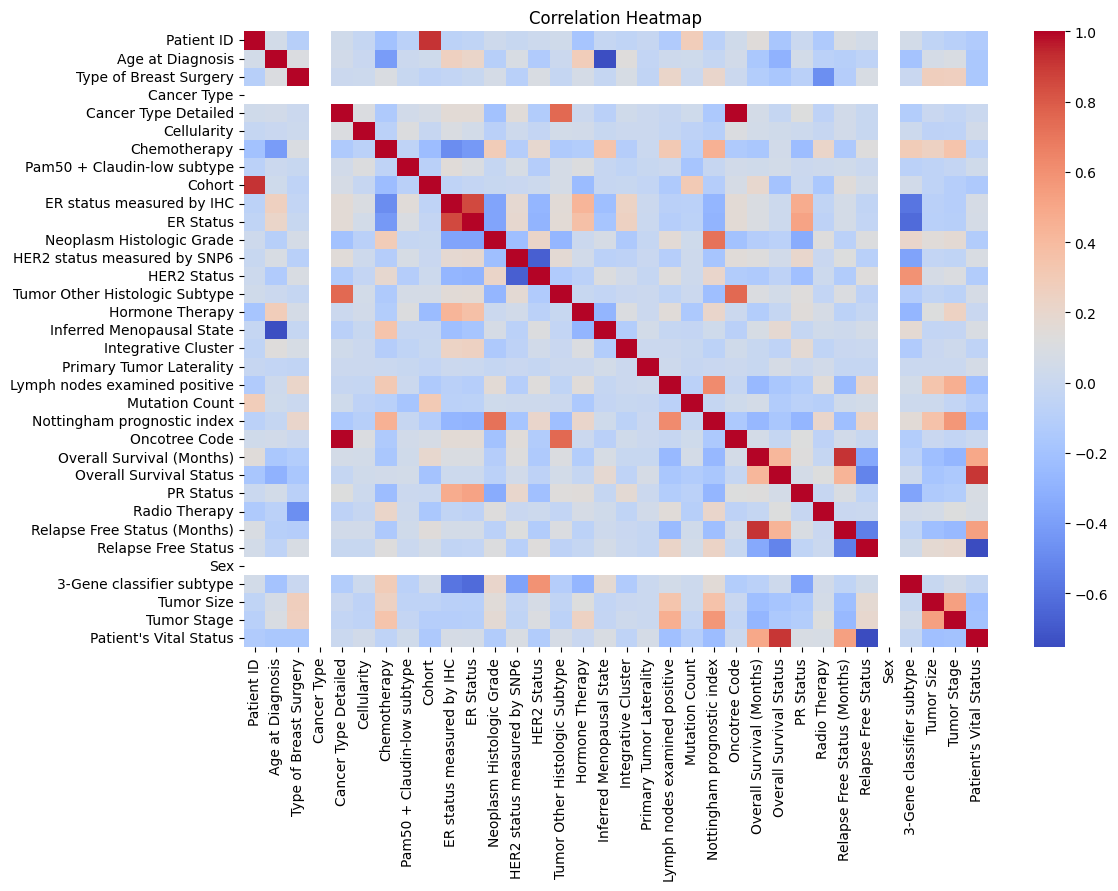

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

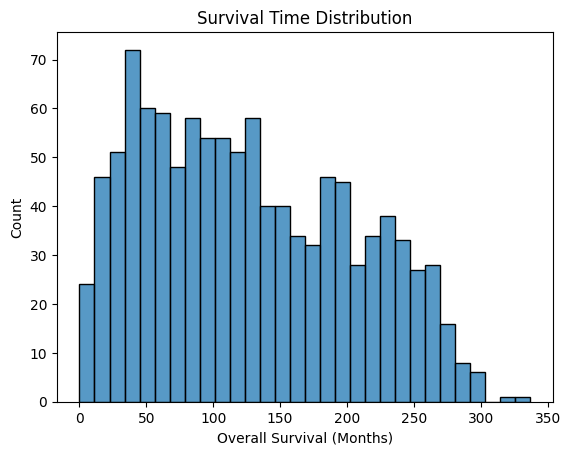

In [8]:
sns.histplot(df['Overall Survival (Months)'], bins=30)
plt.title("Survival Time Distribution")
plt.show()

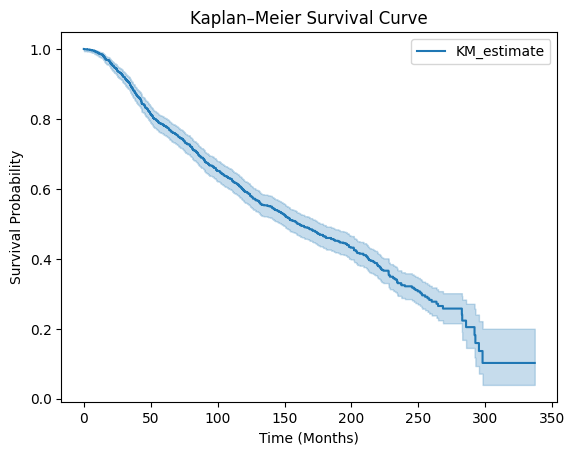

In [9]:
km = KaplanMeierFitter()

T = df["Overall Survival (Months)"]     # time in months
E = 1 - df["Overall Survival Status"]  # 1 = dead, 0 = alive (assuming 'Deceased' was mapped to 0 and 'Living' to 1)

km.fit(T, event_observed=E)
km.plot()
plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()

In [10]:
cox_df = df.copy()

# Drop columns identified as problematic due to low variance or high collinearity
cox_df = cox_df.drop(columns=[
    'Patient ID', 'Cancer Type', 'Sex', "Patient's Vital Status",
    'ER status measured by IHC', 'HER2 status measured by SNP6',
    'Oncotree Code', 'Cancer Type Detailed', 'Tumor Other Histologic Subtype',
    '3-Gene classifier subtype', 'Relapse Free Status (Months)'
])

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='Overall Survival (Months)', event_col='Overall Survival Status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1092 total observations, 608 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'Overall Survival Status'
      baseline estimation = breslow
   number of observations = 1092
number of events observed = 484
   partial log-likelihood = -2575.76
         time fit was run = 2025-12-18 10:15:01 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis              -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Type of Breast Surgery        -0.24      0.79      0.13           -0.48            0.01                0.62                1.01
Cellularity                    0.03      1.04      0.05           -0.06            0.13                0.94                1.14
Chemotherapy                   0.42      1.52      0.17            0.09            0.75                1.09                2.11
Pam50 + Claudin-low subtype    0.01      1.01      0.03           -0.04            0.07                0.96                1.07
Cohort                        -0.61      0.54      0.07           -0.75           -0.47                0.47                0.62
ER Status                     -0.18      0.83      0.17           -0.51            0.14                0.60                1.15
Neoplasm Histologic Grade      0.26      1.29      0.15           -0.03            0.55                0.97                1.72
HER2 Status                    0.26      1.30      0.17           -0.08            0.60                0.92                1.82
Hormone Therapy                0.33      1.39      0.12            0.09            0.57                1.10                1.77
Inferred Menopausal State     -0.04      0.96      0.16           -0.36            0.28                0.70                1.32
Integrative Cluster           -0.02      0.98      0.02           -0.05            0.01                0.95                1.01
Primary Tumor Laterality       0.16      1.18      0.09           -0.02            0.35                0.98                1.41
Lymph nodes examined positive  0.06      1.06      0.02            0.01            0.11                1.01                1.11
Mutation Count                -0.04      0.96      0.02           -0.07           -0.00                0.93                1.00
Nottingham prognostic index   -0.39      0.68      0.14           -0.65           -0.12                0.52                0.88
PR Status                      0.14      1.15      0.12           -0.08            0.37                0.92                1.45
Radio Therapy                  0.19      1.21      0.14           -0.09            0.47                0.92                1.60
Relapse Free Status           -1.01      0.36      0.15           -1.30           -0.73                0.27                0.48
Tumor Size                    -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
Tumor Stage                    0.18      1.20      0.13           -0.07            0.43                0.93                1.54

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00 -0.19   0.85      0.24
Type of Breast Surgery           0.00 -1.87   0.06      4.02
Cellularity                      0.00  0.69   0.49      1.04
Chemotherapy                     0.00  2.49   0.01      6.29
Pam50 + Claudin-low subtype      0.00  0.46   0.64      0.63
Cohort                           0.00 -8.63 <0.005     57.20
ER Status                        0.00 -1.12   0.26      1.92
Neoplasm Histologic Grade        0.00  1.72   0.08      3.56
HER2 Status                      0.00  1.49   

In [11]:
df['10yr_mortality'] = (df['Overall Survival (Months)'] < 120) & (df['Overall Survival Status'] == 0) # Assuming 'Deceased' is 0 after LabelEncoding
df['10yr_mortality'] = df['10yr_mortality'].astype(int)

In [12]:
X = df.drop(['10yr_mortality'], axis=1)
y = df['10yr_mortality']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [15]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression Accuracy: 0.9817351598173516
ROC-AUC: 0.9982514425598881


In [16]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]))

SVM Accuracy: 0.9680365296803652
ROC-AUC: 0.9943171883196363


In [17]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


Random Forest Accuracy: 1.0
ROC-AUC: 1.0


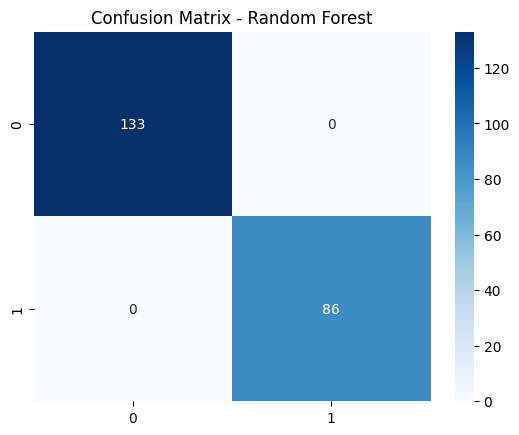

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

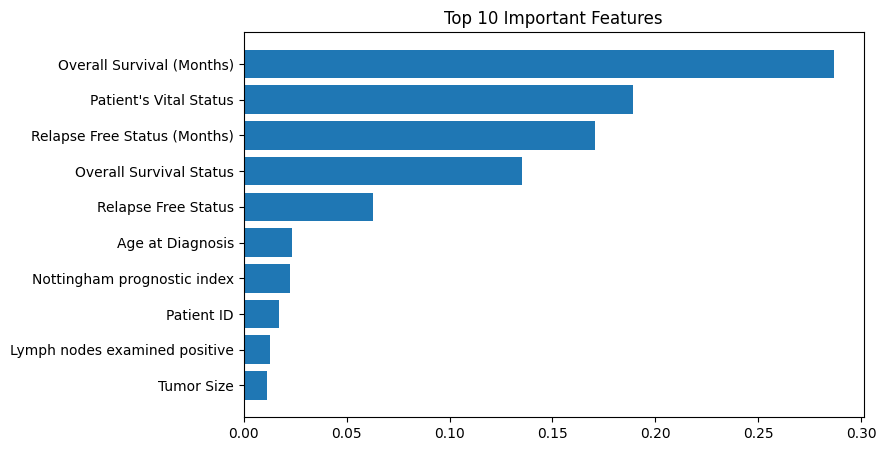

In [19]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]   # top 10 features

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Important Features")
plt.show()

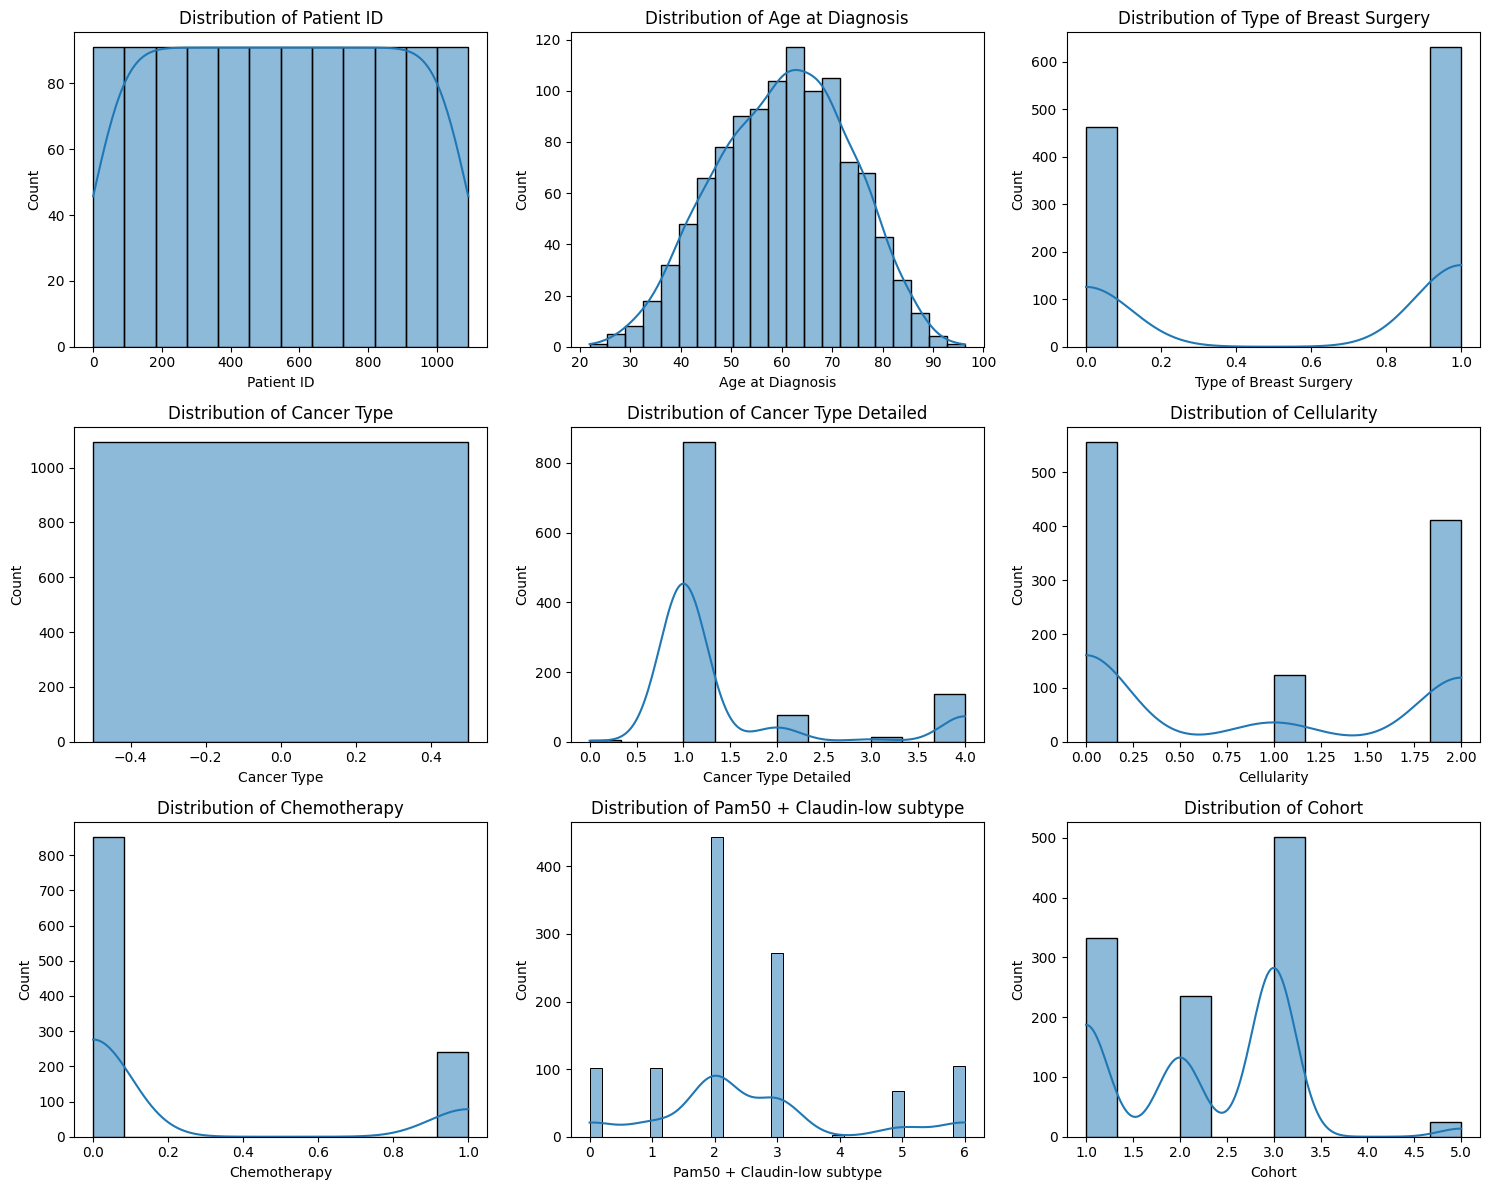

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-load and preprocess df to ensure it's defined
df = pd.read_csv("/content/Breast Cancer METABRIC.csv")   # Adjust path if needed
df = df.dropna()

cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Recreate the '10yr_mortality' column
df['10yr_mortality'] = (df['Overall Survival (Months)'] < 120) & (df['Overall Survival Status'] == 0)
df['10yr_mortality'] = df['10yr_mortality'].astype(int)

num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols[:9], 1):   # first 9 numerical columns
    plt.subplot(3,3,i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [21]:
def breast_cancer_chatbot():
    print("Welcome to the Breast Cancer Data Analysis Chatbot!")
    print("I can provide information about the dataset, the models trained, and their results.")
    print("You can ask me things like:")
    print("- 'What is this dataset about?'")
    print("- 'How did the models perform?'")
    print("- 'Show feature importance'")
    print("- 'Survival curve information'")
    print("- 'Cox PH model information'")
    print("- 'Exit'")

    while True:
        query = input("\nYour query: ").lower()

        if "exit" in query or "quit" in query:
            print("Goodbye!")
            break
        elif "dataset" in query or "about" in query:
            print("This dataset contains clinical and genomic data for breast cancer patients, including age at diagnosis, tumor characteristics, treatment information, and survival outcomes.")
            print(f"It has {len(df)} entries and {len(df.columns)} columns after preprocessing (after dropping NaNs).")
        elif "models" in query or "perform" in query:
            print("We trained Logistic Regression, SVM, and Random Forest models for 10-year mortality prediction.")
            print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr.predict(X_test)):.4f}, ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")
            print(f"SVM Accuracy: {accuracy_score(y_test, svm.predict(X_test)):.4f}, ROC-AUC: {roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]):.4f}")
            print(f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.4f}, ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")
            print("The Random Forest model achieved the best performance in this analysis.")
        elif "feature importance" in query or "features" in query:
            print("Here are the top 10 important features identified by the Random Forest model:")
            for i, idx in enumerate(indices):
                print(f"{i+1}. {X.columns[idx]}: {importances[idx]:.4f}")
        elif "survival curve" in query or "kaplan-meier" in query:
            print("The Kaplan-Meier survival curve shows the probability of survival over time. The plot (generated earlier) illustrates the decreasing survival probability as time progresses.")
        elif "cox ph" in query or "cox proportional hazards" in query:
            print("The Cox Proportional Hazards model was used to analyze the effect of various covariates on survival. Its detailed summary provides hazard ratios and p-values for each feature, indicating their significance. You can refer to the output of `cph.print_summary()` for the specific results.")
        else:
            print("I'm sorry, I don't understand that query. Please try asking something else or 'exit'.")

In [ ]:

breast_cancer_chatbot()

Welcome to the Breast Cancer Data Analysis Chatbot!
I can provide information about the dataset, the models trained, and their results.
You can ask me things like:
- 'What is this dataset about?'
- 'How did the models perform?'
- 'Show feature importance'
- 'Survival curve information'
- 'Cox PH model information'
- 'Exit'

Your query: What is this dataset about?
This dataset contains clinical and genomic data for breast cancer patients, including age at diagnosis, tumor characteristics, treatment information, and survival outcomes.
It has 1092 entries and 35 columns after preprocessing (after dropping NaNs).

Your query: How did the models performs?
We trained Logistic Regression, SVM, and Random Forest models for 10-year mortality prediction.
Logistic Regression Accuracy: 0.9817, ROC-AUC: 0.9983
SVM Accuracy: 0.9680, ROC-AUC: 0.9943
Random Forest Accuracy: 1.0000, ROC-AUC: 1.0000
The Random Forest model achieved the best performance in this analysis.
